In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("default")

fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")
nav_history = pd.read_csv("../data/processed/02_nav_history_clean.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")
category = pd.read_csv("../data/processed/05_category_inflows_clean.csv")
folios = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")
performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
holdings = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

In [2]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

nav_plot = nav_history.merge(
    fund_master[["amfi_code","scheme_name"]],
    on="amfi_code"
)

fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trends (2022–2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    annotation_text="2024 Correction"
)

fig.show()

In [3]:
fig.write_image("../reports/nav_trend.png")

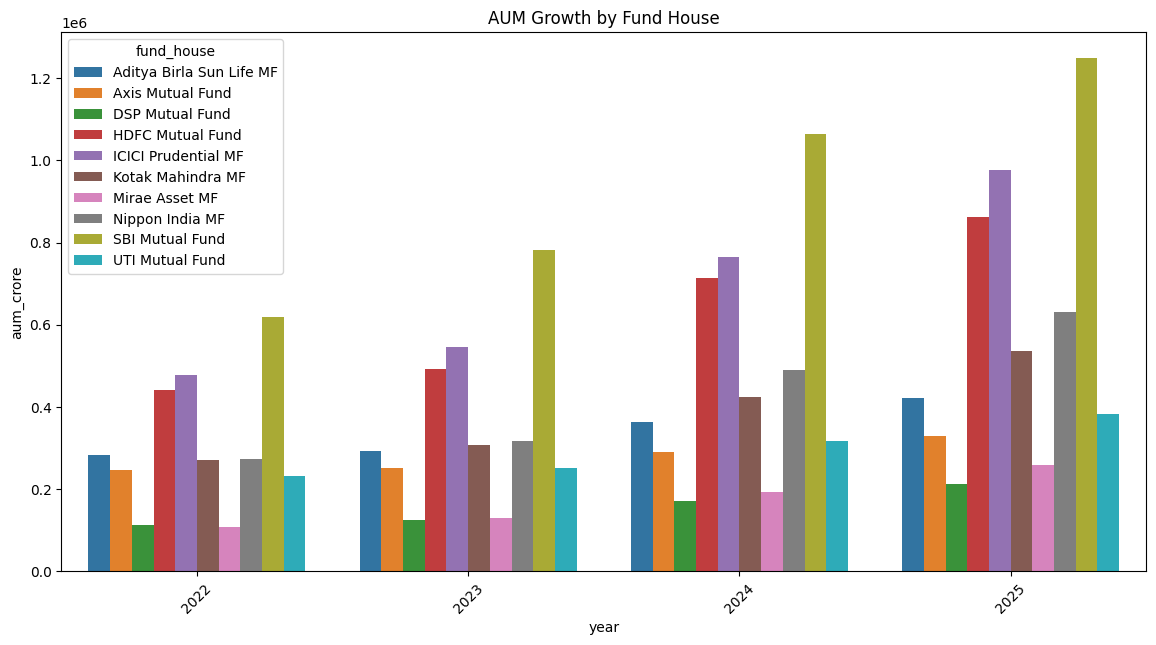

In [4]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

yearly_aum = (
    aum.groupby(
        ["fund_house","year"]
    )["aum_crore"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14,7))

sns.barplot(
    data=yearly_aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.xticks(rotation=45)

plt.show()

In [5]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows"
)

peak = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

fig.add_annotation(
    x=peak["month"],
    y=peak["sip_inflow_crore"],
    text="All Time High"
)

fig.show()

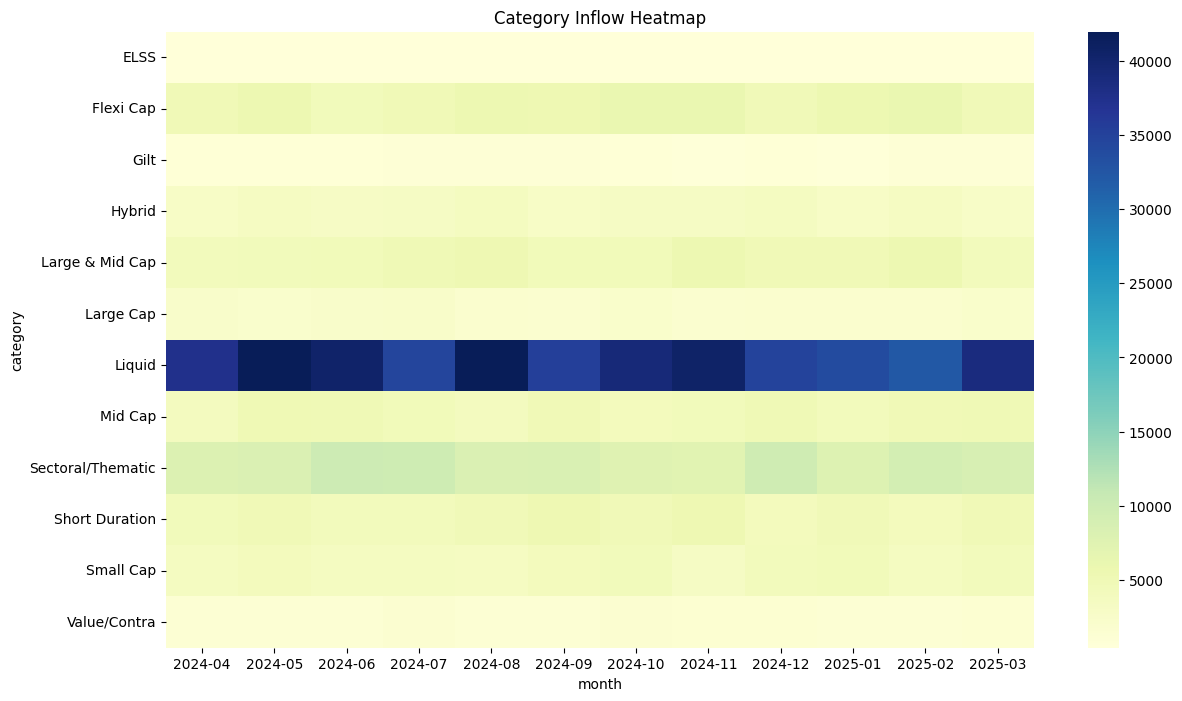

In [6]:
pivot = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(14,8))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.show()

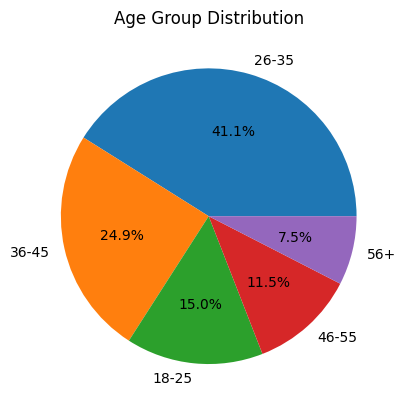

In [7]:
transactions["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Age Group Distribution")

plt.show()

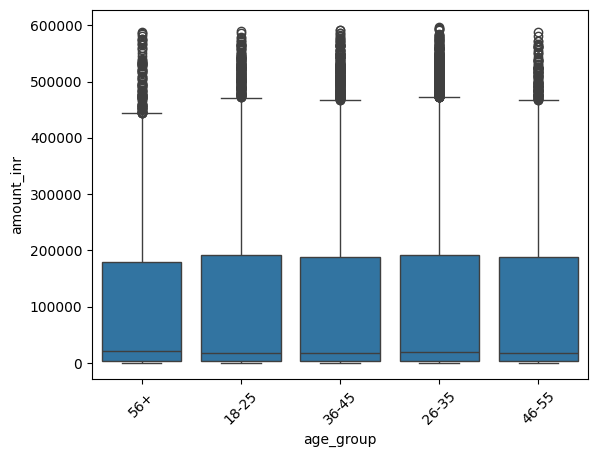

In [8]:
sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.xticks(rotation=45)

plt.show()

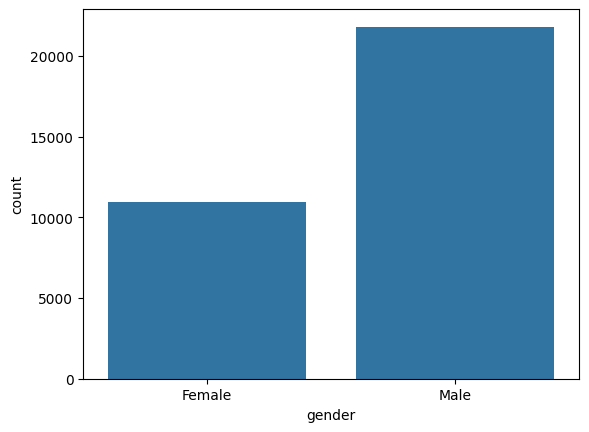

In [9]:
sns.countplot(
    data=transactions,
    x="gender"
)

plt.show()

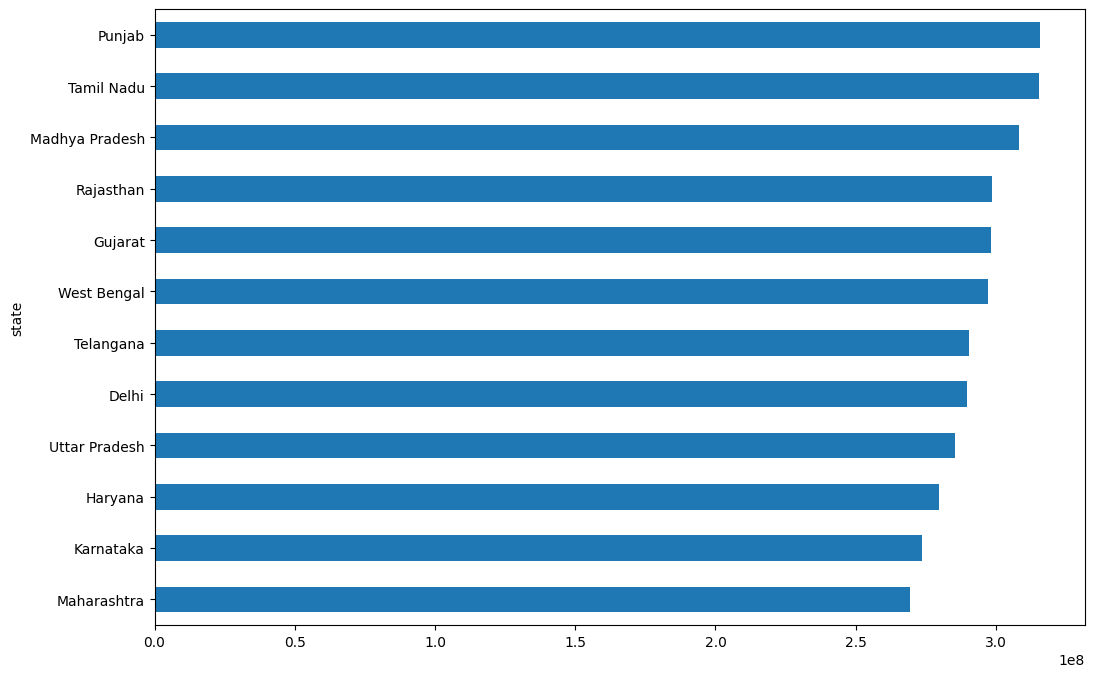

In [10]:
state_data = (
    transactions.groupby("state")
    ["amount_inr"]
    .sum()
    .sort_values()
)

state_data.plot(
    kind="barh",
    figsize=(12,8)
)

plt.show()

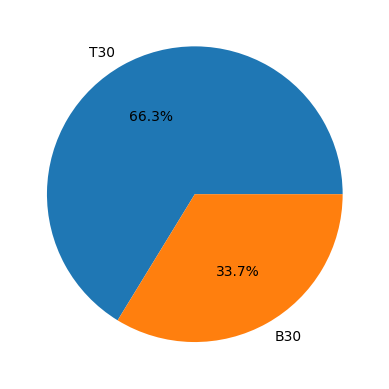

In [11]:
transactions["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.show()

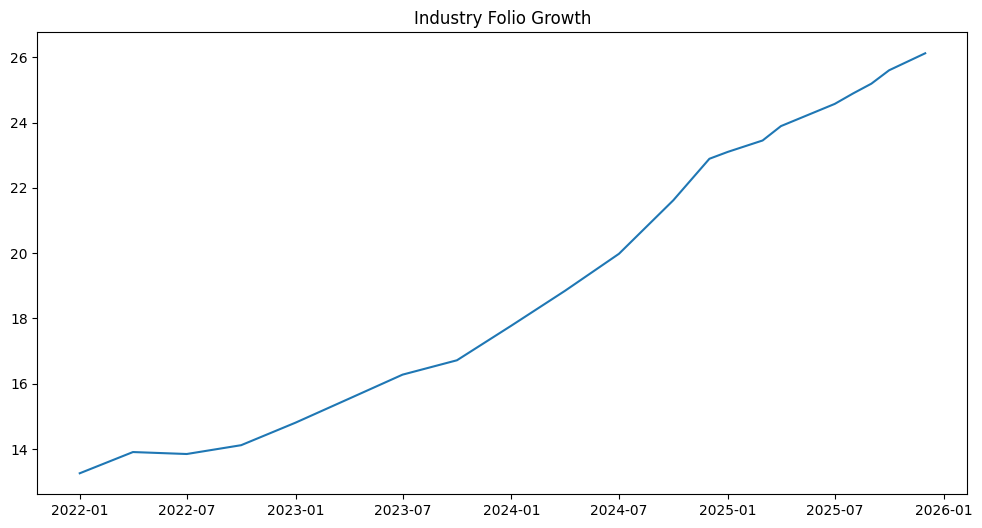

In [12]:
folios["month"] = pd.to_datetime(
    folios["month"]
)

plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"]
)

plt.title(
    "Industry Folio Growth"
)

plt.show()

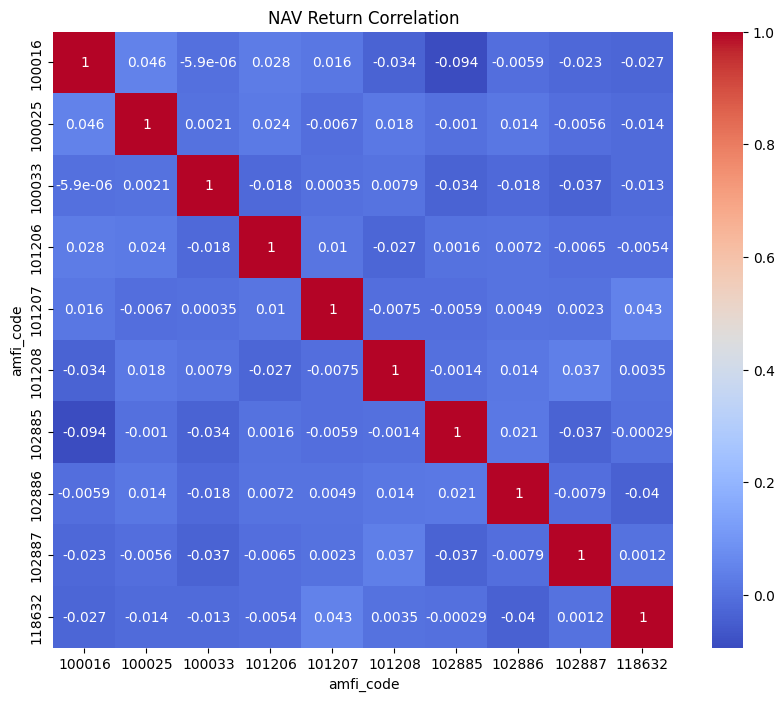

In [13]:
selected = (
    nav_history["amfi_code"]
    .unique()[:10]
)

corr_df = (
    nav_history[
        nav_history["amfi_code"]
        .isin(selected)
    ]
    .pivot(
        index="date",
        columns="amfi_code",
        values="nav"
    )
)

returns = corr_df.pct_change()

corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "NAV Return Correlation"
)

plt.show()

In [14]:
sector = (
    holdings.groupby("sector")
    ["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

fig = px.pie(
    values=sector.values,
    names=sector.index,
    hole=0.5,
    title="Sector Allocation"
)

fig.show()

### Finding 1

NAV values exhibited a strong upward trend during the 2023 market rally, with most large-cap schemes reaching new highs.

### Finding 2

SIP inflows increased steadily through the study period, reaching an all-time high in December 2025.

### Finding 3

AUM concentration remains dominated by a few large fund houses, indicating strong market consolidation.